## Linear Analysis of vocal tract spatial discretization

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc

In [13]:
# Tube setting 
l0 = 17e-2 # Tube length (m)
def area_function(x):
    return np.ones_like(x) * np.pi * 1e-4 #* (1 - 0.8 * np.sin(2 * np.pi * x / l0))


In [70]:
class VocalTract:
    def __init__(self, N = 20, l0 = 17e-2):
        # Some physical constants
        self.c0 = 340 # Sound velocity (m/s)
        self.rho0 = 1.2 # Rest density (kg/m^3)

        self.mw = 15# Wall surface mass (kg/m^2)
        self.kw =self.mw * (2 * np.pi*70)**2 # Wall surface stiffness (N/m^3)
        self.bw = 16000 # Wall surface damping

        self.l0 = l0

        self.N = N
        self.h = self.l0 / (self.N-0.5)

        self.wall_factor = 1

    def setS(self, Sfunc):
        self.S = Sfunc
        self.discreteS()
        # Update matrices
        self.updateParams()

    def discreteS(self):
        self.xd = np.linspace(-self.h/2, self.l0+self.h /
                              2, self.N+1, endpoint=True)
        self.x = np.linspace(0, self.l0, self.N, endpoint=True)
        self.Sdirect = self.S(self.xd)
        self.Sdirect[0] = self.Sdirect[1]
        self.Sdirect[-1] = self.Sdirect[-2]
        self.Sp = 0.5 * (self.Sdirect[:-1] + self.Sdirect[1:])
        self.Sd = self.Sdirect[1:-1]

        # Bounds
        self.Sp = np.maximum(self.Sp, 1e-10)
        self.Sd = np.maximum(self.Sd, 1e-10)

    def updateParams(self):
        rout = np.sqrt(self.Sp[-1] / np.pi)
        Z0 = self.rho0 * self.c0 / self.Sp[-1]
        self.Lrad = 8 * rout / (3 * np.pi * self.c0) * Z0
        self.Rrad = 128/(9*np.pi**2) * Z0

        self.perimeters = 2 * np.pi * \
            np.sqrt(self.Sp / np.pi) * self.wall_factor

    def plotDiscreteS(self):
        plt.figure()
        plt.scatter(self.x, self.Sp, label="Sp", marker="x")
        plt.scatter(self.xd[1:-1], self.Sd, label="Sd", marker="o")
        plt.scatter(self.xd, self.Sdirect, marker=".")
        plt.legend()
        plt.xlabel("Position (m)")
        plt.ylabel("Area (m^2)")

    def computeImpedanceTFLaplace(self, walls=False, method= 0):
        # Returns functions of frequency to estimate impedance and transfer function as function of frequency.
        # The wall flags can be used to include yielding wall coupling.
        # Method 0 is non-centered at the boundary, method 1 is centered at the boundary. These give rather different results at the boundary, with method 1 being the best (it seems).
        self.updateParams()

        self.Gl = np.zeros(self.N)
        self.Gl[-1] = 1
        self.Gg = np.zeros(self.N)
        self.Gg[0] = 1

        # Finite differences matrices
        self.Dplus = np.zeros((self.N, self.N-1))
        self.Dplus[:self.N-1, :self.N-1] += 1/self.h * np.eye(self.N-1)
        self.Dplus[1:, :self.N-1] += -1/self.h * np.eye(self.N-1)
        if method == 1:
            # self.Dplus[0, 0] *= 2
            self.Dplus[-1, -1] *= 2
        self.Dmin = - self.Dplus.T
        self.D2 = self.Dplus @ self.Dmin

        if walls:
            self.H = sc.linalg.block_diag(self.h * np.diag(self.Sd) * self.rho0,
                                          self.h *
                                          np.diag(self.Sp) *
                                          self.c0**2 / self.rho0,
                                          self.h *
                                          np.diag(self.perimeters / self.mw),
                                          self.h *
                                          np.diag(self.perimeters * self.kw),
                                          self.Lrad)
            if method == 1:
                self.H[self.N-1 + self.N - 1] *= 1/2
            S0 = - self.Dmin @ np.diag(1 / self.Sp)
            SRrad = - self.rho0**2 / \
                (self.h * self.Rrad) * np.diag(self.Gl /
                                               # np.diag(np.ones_like(self.Gl))
                                               (self.Sp**2)) + 2 * 6.9 * self.rho0 * 1e-3 * self.D2 * 0
            if (method==1):
                SRrad *= 4
            # Rvisc = - 1e-2 / self.h * np.ones_like(self.Sp)
            SLrad = np.expand_dims(- self.rho0/self.Lrad *
                                   np.diag(1 / self.Sp) @ self.Gl.T, axis=1)
            if (method==1):
                SLrad *= 2
            SRw = - np.diag(self.bw / self.perimeters)
            S0w = - np.diag(1 / self.perimeters)
            Sfw = - 1 * np.diag(self.rho0 / self.Sp)
            self.Sxx = 1 / self.h * sc.sparse.block_array(
                [[None, S0, None, None, None],
                 [- S0.T, SRrad, Sfw, None, SLrad],
                 [None, -Sfw.T, SRw, S0w, None],
                 [None, None, -S0w.T, None, None],
                 [None, -SLrad.T, None, None, None]]
            ).toarray()
            self.Sxu = 1/self.h * sc.sparse.block_array(
                [[np.zeros((len(self.Sd))), self.rho0 * 1/self.Sp *
                  self.Gg, np.zeros(1 + 2 * len(self.Sp))]]
            ).toarray().T
            matoutZ = self.Sxu.T @ self.H

            matoutTF = np.zeros_like(self.Sxu.T)
            # matoutTF[0, len(self.Sd) + len(self.Sp) -1] = self.rho0 * 1 / (self.h * self.Sp[-1])
            matoutTF[0, len(self.Sd) + len(self.Sp) - 1] = 1 / \
                self.Rrad * self.rho0 * 1 / (self.h * self.Sp[-1])
            matoutTF[0, -1] = 1 / self.Lrad
            matoutTF = matoutTF @ self.H

            matinternal = self.Sxx @ self.H

            def impedanceFunc(s):
                return complex((matoutZ @ np.linalg.inv(s * np.eye(len(self.H)) - matinternal) @ self.Sxu)[0, 0])

            def TFFunc(s):
                return complex((matoutTF @ np.linalg.inv(s * np.eye(len(self.H)) - matinternal) @ self.Sxu)[0, 0])
            return impedanceFunc, TFFunc, matinternal
        else:
            self.H = sc.linalg.block_diag(self.h * np.diag(self.Sd) * self.rho0,
                                          self.h *
                                          np.diag(self.Sp) *
                                          self.c0**2 / self.rho0,
                                          self.Lrad)
            if method == 1:
                # self.H[self.N-1] *= 1/2
                self.H[self.N-1 + self.N - 1] *= 1/2
            S0 = - self.Dmin @ np.diag(1 / self.Sp)
            S1 = - self.rho0**2 / (self.h * self.Rrad) * \
                np.diag(self.Gl / (self.Sp**2))
            if method ==1:
                S1 *= 4
            S2 = np.expand_dims(- self.rho0/self.Lrad *
                                np.diag(1 / self.Sp) @ self.Gl.T, axis=1)
            if method ==1:
                S2 *= 2
            self.Sxx = 1 / self.h * sc.sparse.block_array(
                [[None, S0, None],
                 [- S0.T, S1, S2],
                 [None, -S2.T, None]]
            ).toarray()
            self.Sxu = 1/self.h * sc.sparse.block_array(
                [[np.zeros((len(self.Sd))), self.rho0 * 1 /
                  self.Sp * self.Gg, np.zeros(1)]]
            ).toarray().T
            # if method ==1:
            #     self.Sxu *= 2
            matoutZ = self.Sxu.T @ self.H
            matinternal = self.Sxx @ self.H

            matoutTF = np.zeros_like(self.Sxu.T)
            matoutTF[0, len(self.Sd) + len(self.Sp) -
                     1] = 1 / \
                self.Rrad * self.rho0 * 1 / (self.h * self.Sp[-1])
            matoutTF[0, -1] = 1 / self.Lrad
            matoutTF = matoutTF @ self.H

            def impedanceFunc(s):
                return complex((matoutZ @ np.linalg.inv(s * np.eye(len(self.H)) - matinternal) @ self.Sxu)[0, 0])

            def TFFunc(s):
                return complex((matoutTF @ np.linalg.inv(s * np.eye(len(self.H)) - matinternal) @ self.Sxu)[0, 0])
            return impedanceFunc, TFFunc, matinternal


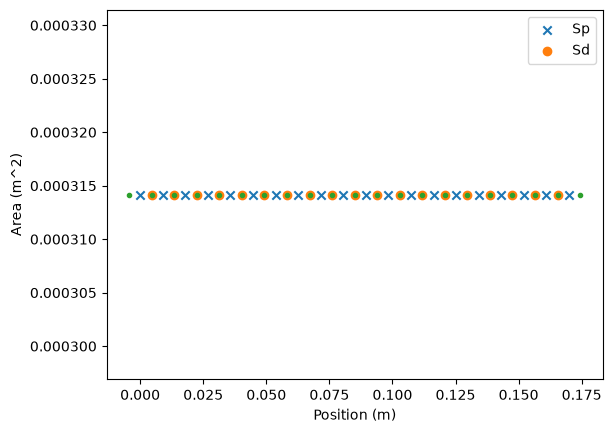

In [75]:
vt = VocalTract(N=20)
vt.setS(area_function)
vt.plotDiscreteS()

In [76]:
impedanceFunc, TFfunc, matinternal = vt.computeImpedanceTFLaplace(walls=False, method=1)

In [77]:
vt.Dplus

array([[ 114.70588235,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ],
       [-114.70588235,  114.70588235,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ],
       [   0.        , -114.70588235,  114.70588235,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ],
       [   0.        ,

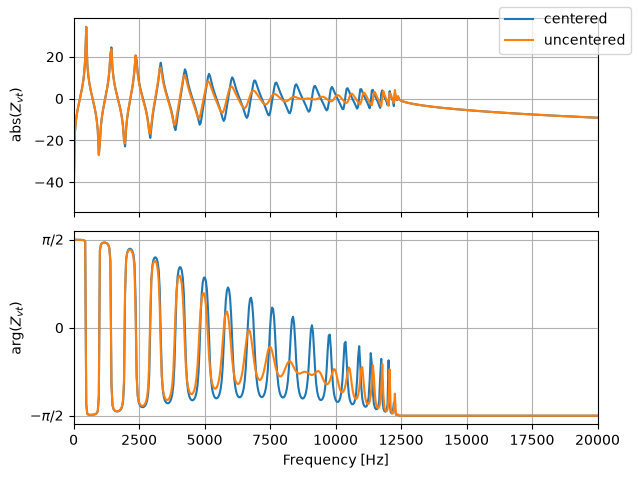

In [79]:
fmax = 20000

impedanceFunc, TFfunc, matinternal = vt.computeImpedanceTFLaplace(walls=False, method=1)

fs = np.linspace(1, fmax, 500)
Zspat = np.zeros_like(fs, dtype = complex)
TF = np.zeros_like(fs, dtype = complex)
TF2 = np.zeros_like(fs, dtype = complex)
for i, fi in enumerate(fs):
  Zspat[i] = impedanceFunc(1j * 2 * np.pi * fi)
  TF[i] = TFfunc(1j * 2 * np.pi * fi)
  TF2[i] = TF[i] / Zspat[i]

fig, axs = plt.subplots(2, sharex=True)

axs[0].plot(fs, 20 * np.log10(np.abs(Zspat) / (vt.c0 * vt.rho0 / (area_function(0)))), label="centered")
axs[1].plot(fs, np.angle(Zspat))



impedanceFunc, TFfunc, matinternal = vt.computeImpedanceTFLaplace(walls=False, method=0)

fs = np.linspace(1, fmax, 500)
Zspat = np.zeros_like(fs, dtype = complex)
TF = np.zeros_like(fs, dtype = complex)
TF2 = np.zeros_like(fs, dtype = complex)
for i, fi in enumerate(fs):
  Zspat[i] = impedanceFunc(1j * 2 * np.pi * fi)
  TF[i] = TFfunc(1j * 2 * np.pi * fi)
  TF2[i] = TF[i] / Zspat[i]

axs[0].plot(fs, 20 * np.log10(np.abs(Zspat) / (vt.c0 * vt.rho0 / (area_function(0)))), label="uncentered")
axs[1].plot(fs, np.angle(Zspat))


axs[0].set_xlim(0, fmax)
# axs[0].set_ylim(1e3, 1e9)

axs[1].set_yticks([-np.pi/2, 0, np.pi/2], [r"$-\pi/2$", 0, r"$\pi/2$"])

for ax in axs:
    ax.grid()

axs[1].set_xlabel("Frequency [Hz]")
axs[1].set_ylabel(r"arg($Z_{vt}$)")
axs[0].set_ylabel(r"abs($Z_{vt}$)")

# axs[0].plot(freq_ref, 20 * np.log10(abs_ref), label="ref")
# axs[1].plot(freq_ref, angle_ref)

fig.legend()

fig.tight_layout()
fig.align_ylabels(axs)
fig.subplots_adjust(hspace=0.1, wspace=0.23)

In [397]:
from numpy import genfromtxt
my_data = genfromtxt('Impedance_25degC.csv', delimiter=' ')

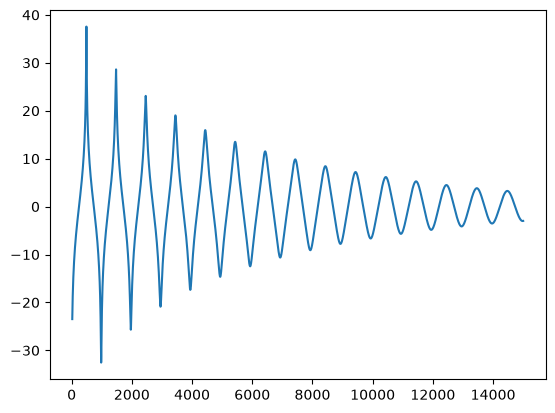

In [408]:
plt.figure()

freq_ref = my_data[:, 0]
Z_ref = my_data[:, 1] + 1j * my_data[:, 2]

abs_ref = np.abs(Z_ref)
angle_ref = np.angle(Z_ref)
plt.plot(freq_ref, 20 * np.log10(abs_ref))